In [2]:
import pandas as pd

df = pd.read_csv('../resources/stack-overflow-developer-survey-2025/survey_results_public.csv')

/var/folders/pm/cr2jym353f5bckqff3dz1l800000gn/T/ipykernel_28848/2466482609.py:3: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../resources/stack-overflow-developer-survey-2025/survey_results_public.csv')


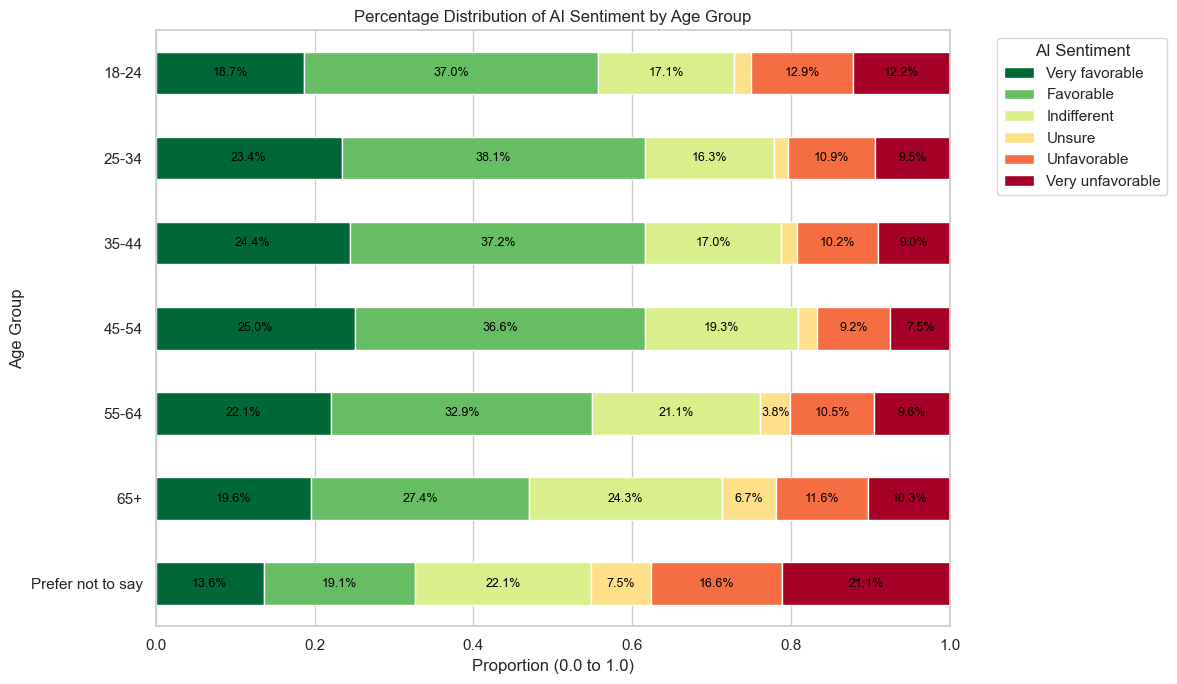

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup and Clean Data
aimodels = df[['AISent', 'Age']].copy()
aimodels = aimodels.dropna()

# --- NEW: Map exact dataset strings to clean labels ---
# This dictionary looks for the exact string on the left, and replaces it with the clean text on the right
age_mapping = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+',
    'Prefer not to say': 'Prefer not to say'
}

# Apply the mapping to create the new AgeGroup column
aimodels['AgeGroup'] = aimodels['Age'].map(age_mapping)

# Define the correct chronological order for the Y-axis
expected_age_order = [
    '18-24', '25-34', '35-44', '45-54', 
    '55-64', '65+', 'Prefer not to say'
]
aimodels['AgeGroup'] = pd.Categorical(aimodels['AgeGroup'], categories=expected_age_order, ordered=True)
# ----------------------------------------------------

# Define exact order for AISent
expected_sent_order = [
    "Very favorable", "Favorable", "Indifferent", 
    "Unsure", "Unfavorable", "Very unfavorable"
]
aimodels['AISent'] = pd.Categorical(aimodels['AISent'], categories=expected_sent_order, ordered=True)

# 2. Create the normalized crosstab
crosstab_percent = pd.crosstab(aimodels['AgeGroup'], aimodels['AISent'], normalize='index')

# 3. Apply Seaborn styling
sns.set_theme(style="whitegrid")

# 4. Plot the 100% stacked HORIZONTAL bar chart
plt.figure(figsize=(12, 7))
ax = crosstab_percent.plot(kind='barh', stacked=True, colormap='RdYlGn_r', ax=plt.gca())

# 5. Add Percentage Labels inside the bars
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    
    # Only show text if the bar segment is larger than 3%
    if width > 0.03:
        center_x = x + width / 2
        center_y = y + height / 2
        
        ax.text(center_x, center_y, f'{width * 100:.1f}%', 
                ha='center', va='center', color='black', fontsize=9)

# 6. Formatting the chart
plt.title('Percentage Distribution of AI Sentiment by Age Group')
plt.xlabel('Proportion (0.0 to 1.0)')
plt.ylabel('Age Group')

plt.xlim(0, 1)
ax.invert_yaxis() # Youngest at the top, down to 'Prefer not to say' at the bottom

# Move legend outside
plt.legend(title='AI Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Display the plot
plt.show()

In [4]:
# Returns an array of all unique age values
unique_ages = df['Age'].unique()
print(unique_ages)

<StringArray>
[  '25-34 years old',   '35-44 years old',   '45-54 years old',
   '18-24 years old', '65 years or older',   '55-64 years old',
 'Prefer not to say']
Length: 7, dtype: str


In [30]:
import pandas as pd


def process_ai_sentiment_by_column(df, col, mapping_col, mapping, expected_order, ai_sent_col='AISent'):
    # 1. Setup and Clean Data
    aimodels = df[[ai_sent_col, col]].copy()
    aimodels = aimodels.dropna()

    aimodels[mapping_col] = aimodels[col].map(mapping)

    aimodels[mapping_col] = pd.Categorical(aimodels[mapping_col], categories=expected_order, ordered=True)

    expected_sent_order = ["Very favorable", "Favorable", "Indifferent", "Unsure", "Unfavorable", "Very unfavorable"]
    aimodels[ai_sent_col] = pd.Categorical(aimodels[ai_sent_col], categories=expected_sent_order, ordered=True)

    # 2. Create the base dataframe of proportions (0.0 to 1.0)
    df_proportions = pd.crosstab(aimodels[mapping_col], aimodels[ai_sent_col], normalize='index')

    # 3. Convert to percentages and round to 2 decimal places
    df_percentages = (df_proportions * 100).round(2)

    # 4. Clean up the dataframe structure
    # Reset index makes 'AgeGroup' a normal column instead of the dataframe's index
    df_percentages = df_percentages.reset_index()

    # Remove the leftover 'AISent' label from the columns axis for a cleaner table
    df_percentages.columns.name = None 

    return df_percentages

def create_plot_from_percentages(df_percentages, column):
    # 1. Apply Seaborn styling
    sns.set_theme(style="whitegrid")

    # 2. Plot the stacked HORIZONTAL bar chart directly from df_percentages
    # By setting x='AgeGroup', pandas knows to use that column for the y-axis labels
    plt.figure(figsize=(12, 7))
    ax = df_percentages.plot(
        x=column, 
        kind='barh', 
        stacked=True, 
        colormap='RdYlGn_r', 
        ax=plt.gca()
    )

    # 3. Add Percentage Labels inside the bars
    for p in ax.patches:
        height = p.get_height()
        width = p.get_width() # Width is now the actual percentage (e.g., 25.5)
        x, y = p.get_xy()
        
        # Only show text if the bar segment is larger than 3%
        if width > 3:
            center_x = x + width / 2
            center_y = y + height / 2
            
            # We no longer multiply by 100, just format the width directly
            ax.text(center_x, center_y, f'{width:.1f}%', 
                    ha='center', va='center', color='black', fontsize=9)

    # 4. Formatting the chart
    plt.title(f'Percentage Distribution of AI Sentiment by "{column}" Level')
    plt.xlabel('Percentage (%)')
    plt.ylabel(column)

    # Explicitly cap the X-axis from 0 to 100
    plt.xlim(0, 100)

    # Invert the Y-axis so the top row of the dataframe (18-24) stays at the top of the plot
    ax.invert_yaxis()

    # Move legend outside the plot area
    plt.legend(title='AI Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()

    # Display the plot
    plt.show()

# get all unique values in a column
def get_unique_values(df, col) -> list:
    unique_values = df[col].unique()
    return list(unique_values)

In [31]:
age_mapping = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+',
    'Prefer not to say': 'Prefer not to say'
}

expected_age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Prefer not to say']

newdf = process_ai_sentiment_by_column(df, col='Age', mapping_col='AgeGroup', mapping=age_mapping, expected_order=expected_age_order)
print(newdf)

            AgeGroup  Very favorable  Favorable  Indifferent  Unsure  \
0              18-24           18.71      36.99        17.10    2.09   
1              25-34           23.43      38.14        16.31    1.76   
2              35-44           24.44      37.21        17.02    2.08   
3              45-54           25.04      36.56        19.28    2.38   
4              55-64           22.06      32.90        21.10    3.84   
5                65+           19.58      27.38        24.34    6.75   
6  Prefer not to say           13.57      19.10        22.11    7.54   

   Unfavorable  Very unfavorable  
0        12.91             12.20  
1        10.90              9.47  
2        10.21              9.04  
3         9.22              7.52  
4        10.46              9.64  
5        11.64             10.32  
6        16.58             21.11  


      Education  Very favorable  Favorable  Indifferent  Unsure  Unfavorable  \
0       Primary           27.56      31.45        16.61    6.01         8.83   
1     Secondary           17.74      32.60        19.94    2.29        13.41   
2     Associate           22.30      35.77        19.17    2.56        10.06   
3      Bachelor           23.84      37.69        16.98    2.05        10.34   
4        Master           24.08      38.34        17.02    2.15        10.08   
5  Professional           21.34      35.87        18.98    2.67        11.38   
6         Other           19.12      35.29        18.14    5.88         8.82   

   Very unfavorable  
0              9.54  
1             14.03  
2             10.15  
3              9.10  
4              8.33  
5              9.75  
6             12.75  


/var/folders/pm/cr2jym353f5bckqff3dz1l800000gn/T/ipykernel_28848/3697093598.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  aimodels[mapping_col] = pd.Categorical(aimodels[mapping_col], categories=expected_order, ordered=True)


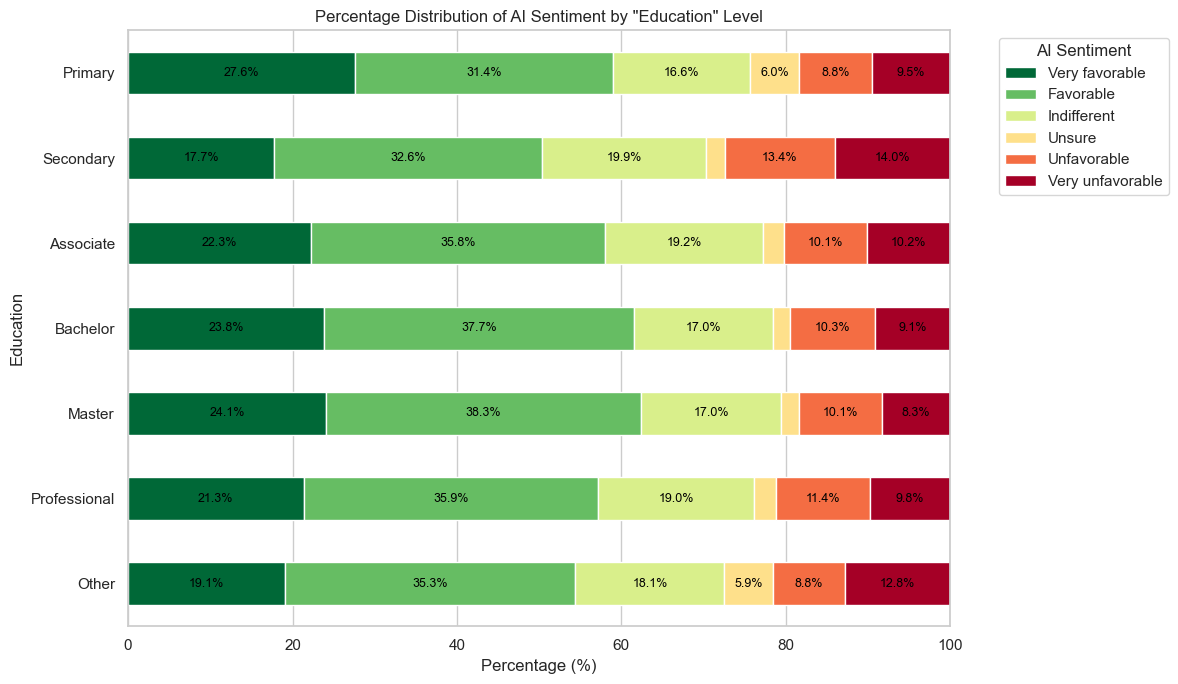

In [32]:
education_mapping = {
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 'Master',
    'Associate degree (A.A., A.S., etc.)': 'Associate',
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 'Bachelor',
    'Some college/university study without earning a degree': 'Some College',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'Professional',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'Secondary',
    'Other (please specify):': 'Other',
    'Primary/elementary school': 'Primary'
}

expected_age_order = ["Primary", "Secondary", "Associate", "Bachelor", "Master", "Professional", "Other"]

df_percentages = process_ai_sentiment_by_column(df, col='EdLevel', mapping_col='Education', mapping=education_mapping, expected_order=expected_age_order)
print(df_percentages)
create_plot_from_percentages(df_percentages, column='Education')

['I am a developer by profession', 'I am not primarily a developer, but I write code sometimes as part of my work/studies', 'I used to be a developer by profession, but no longer am', 'I code primarily as a hobby', 'I work with developers or my work supports developers but am not a developer by profession', 'I am learning to code']
                    Profession  Very favorable  Favorable  Indifferent  \
0                    Developer           23.54      37.67        17.40   
1  Non-Developer (Code Writer)           20.70      35.93        18.43   
2             Former Developer           20.15      32.39        21.45   
3                     Hobbyist           13.32      24.79        19.63   
4                 Support Role           29.67      35.33        16.64   
5                     Learning           25.45      37.20        14.37   

   Unsure  Unfavorable  Very unfavorable  
0    1.75        10.55              9.09  
1    2.97        11.46             10.51  
2    3.90        1

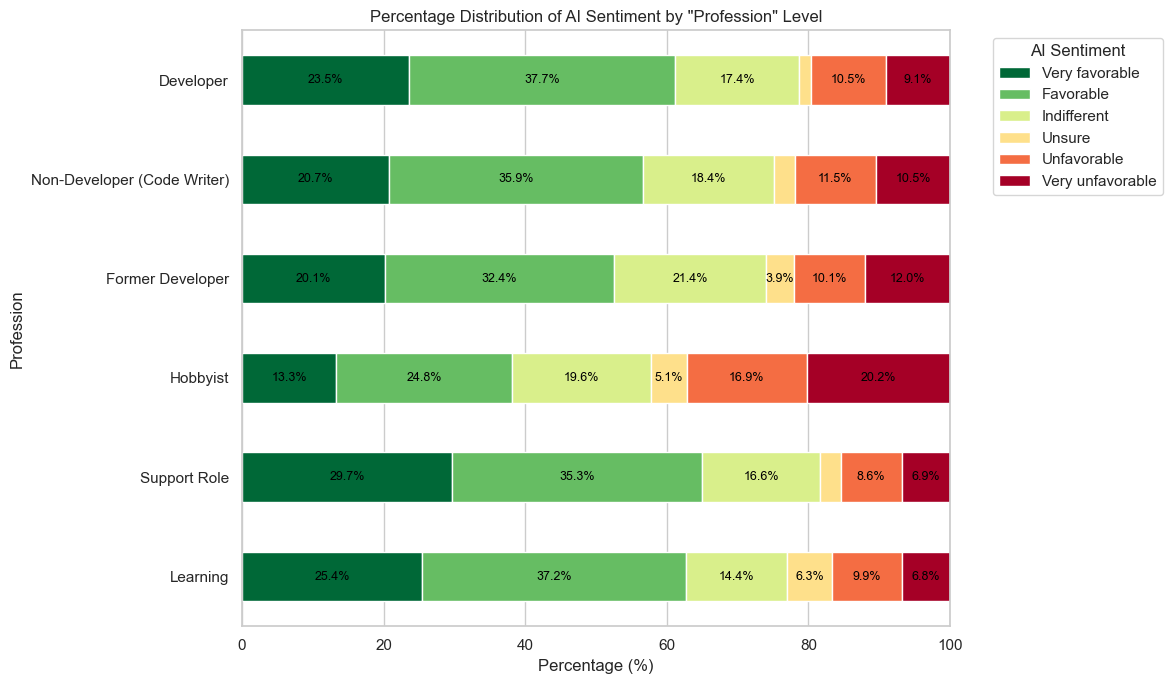

In [33]:
# "MainBranch","Age","EdLevel","Employment","EmploymentAddl","WorkExp"

print(get_unique_values(df, 'MainBranch'))

proffesion_mapping = {
    'I am a developer by profession': 'Developer',
    'I am not primarily a developer, but I write code sometimes as part of my work/studies': 'Non-Developer (Code Writer)',
    'I used to be a developer by profession, but no longer am': 'Former Developer',
    'I code primarily as a hobby': 'Hobbyist',
    'I work with developers or my work supports developers but am not a developer by profession': 'Support Role',
    'I am learning to code': 'Learning'
}


expected_profession_order = ["Developer", "Non-Developer (Code Writer)", "Former Developer", "Hobbyist", "Support Role", "Learning"]

df_percentages = process_ai_sentiment_by_column(df, col='MainBranch', mapping_col='Profession', mapping=proffesion_mapping, expected_order=expected_profession_order)
print(df_percentages)
create_plot_from_percentages(df_percentages, column='Profession')
